In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Formula for Negaive Image
##### for 8-bit image     g(x,y)= 255 - f(x,y)

Image loaded successfully.


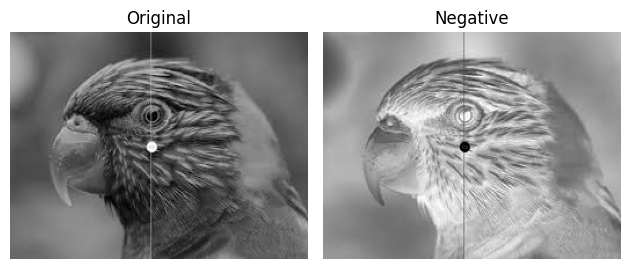

In [22]:
img= cv2.imread("images/image.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
else:
    print("Image loaded successfully.")

    
negative = 255 - img
negative2 =cv2.bitwise_not(img)
plt.Figure(figsize=(12,4))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img, cmap="gray"); plt.axis('off')

plt.subplot(1,2,2); plt.title("Negative"); plt.imshow(negative, cmap="gray"); plt.axis('off')
plt.tight_layout()
plt.show()

### LOGARITHMIC TRANSFORMATION

### formula: g(x,y) = c * log(1 + r)
##### say this is a 8-bit image
### where c = 255 / log(1 + max_pixel_value)

In [23]:
import cv2; import numpy as np; import matplotlib.pyplot as plt
img= cv2.imread("images/dog.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    print("No such image found in the directory")
else:
    print("Image loaded successfully")
    

Image loaded successfully


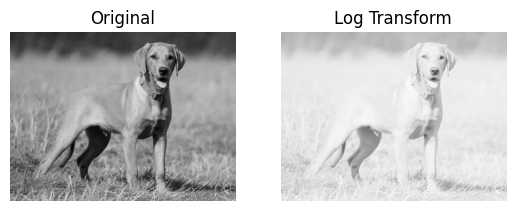

In [24]:
## claculate for c
c = 255 / np.log(1 + np.max(img))

log_img = c * np.log(1 + img.astype(np.float32))
log_img = np.array(log_img, dtype=np.uint8)

plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(log_img, cmap='gray'); plt.title('Log Transform'); plt.axis('off')
plt.show()

#### 4. Power-law (Gamma) Transformation — formula, graph, code


##### Mathematical Definition
##### (𝑥,𝑦)=𝑐⋅𝑓(𝑥,𝑦)^𝛾
##### Where:
##### 𝛾 controls curve shape. That is the gamma value
##### 𝛾 controls curve shape. That is the gamma value
##### 𝑐 scaling constant
##### Behaviour
#### 𝛾<1→ Brightens image
##### 𝛾>1→ Darkens image
#### Used in gamma correction (displays, cameras)


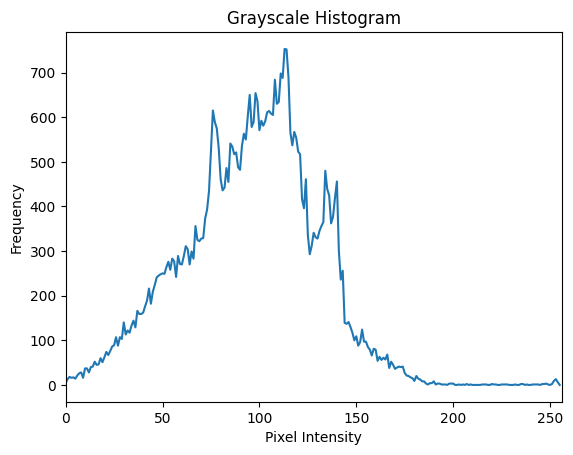

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('images/image.jpg', cv2.IMREAD_GRAYSCALE)

# Calculate histogram using OpenCV
hist = cv2.calcHist([img], [0], None, [256], [0, 256]) # this means we are calculating the histogram for the grayscale image (channel 0), with no mask, 256 bins, and pixel intensity range from 0 to 255., [img] is the source image, [0] is the channel index (0 for grayscale), None means no mask, [256] is the number of bins, and [0, 256] is the range of pixel intensity values.
# bins mean the number of intervals we want to divide the pixel intensity range into. In this case, we are using 256 bins, which means each bin will represent a pixel intensity value from 0 to 255.

# Plot the histogram using matplotlib
plt.figure() # creates a new figure for plotting. This is useful if you want to create multiple plots in the same script without them overlapping.
plt.title('Grayscale Histogram') # sets the title of the plot to 'Grayscale Histogram'.
plt.xlabel('Pixel Intensity') # sets the label of the x-axis to 'Pixel Intensity'.
plt.ylabel('Frequency') # sets the label of the y-axis to 'Frequency'.
plt.plot(hist) # plots the histogram data. The x-axis will represent pixel intensity values (0 to 255), and the y-axis will represent the frequency of each intensity value in the image.
plt.xlim([0, 256]) # sets the limits of the x-axis to be from 0 to 256. This ensures that the x-axis covers the full range of pixel intensity values.
plt. show() # displays the plot on the screen.

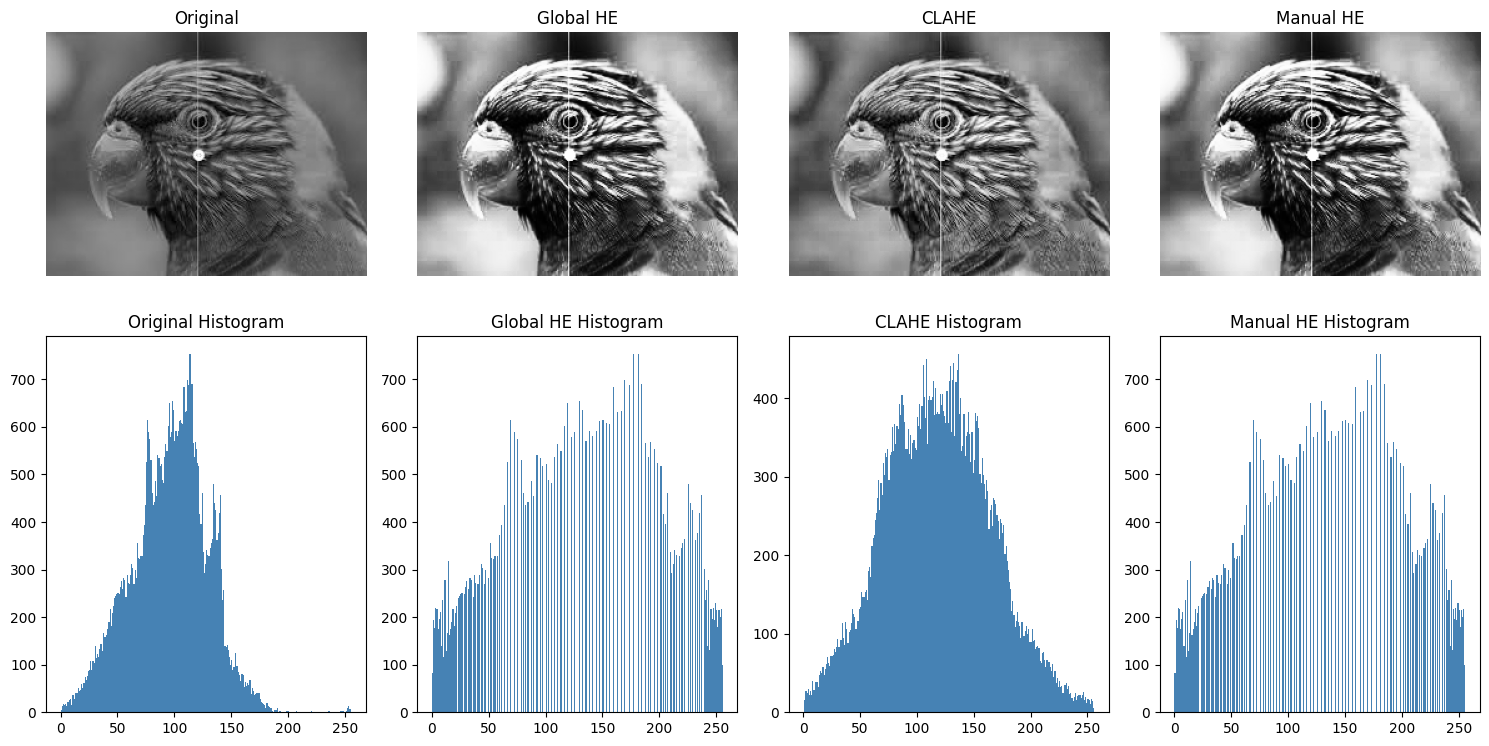

In [26]:
# ── 2. Global Histogram Equalization ────────────────────────────
eq_global = cv2.equalizeHist(img)
# equalizeHist: computes histogram, CDF, applies s=255*CDF(r) mapping
# ONLY works on single-channel (grayscale) uint8 images

# ── 3. CLAHE ────────────────────────────────────────────────────
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
eq_clahe = clahe.apply(img)
# clipLimit: max histogram height before clipping (higher = more contrast)
# tileGridSize: number of tiles in (cols, rows) — (8,8) = 64 tiles

# ── 4. Manual CDF-based equalization (shows the math) ───────────
hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])
cdf = hist.cumsum()                     # running cumulative sum = CDF (unnormalized)
cdf_min = cdf[cdf > 0].min()            # smallest non-zero CDF value
N = img.shape[0] * img.shape[1]        # total pixels = height × width

# Apply formula: s = round((CDF(r) - CDF_min) / (N - CDF_min) * 255)
cdf_norm = np.round((cdf - cdf_min) / (N - cdf_min) * 255).astype(np.uint8)
eq_manual = cdf_norm[img]               # look up each pixel's new value in the mapping

# ── 5. Display comparison ────────────────────────────────────────
plt.figure(figsize=(15, 8))
images = [(img,'Original'), (eq_global,'Global HE'),
           (eq_clahe,'CLAHE'), (eq_manual,'Manual HE')]

for i, (im, title) in enumerate(images):
    plt.subplot(2, 4, i+1)
    plt.imshow(im, cmap='gray'); plt.title(title); plt.axis('off')
    plt.subplot(2, 4, i+5)
    plt.hist(im.ravel(), bins=256, range=[0,256], color='steelblue')
    plt.title(title + ' Histogram')

plt.tight_layout(); plt.show()

(np.float64(0.0), np.float64(256.0), np.float64(-37.65), np.float64(790.65))

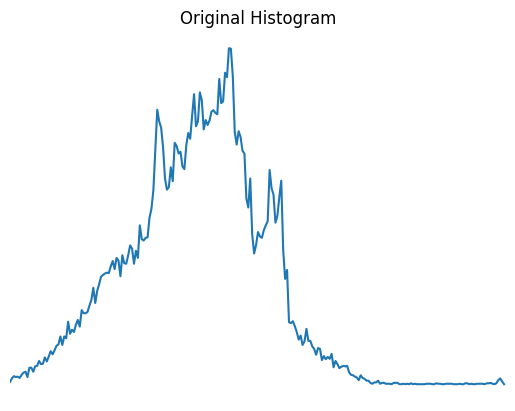

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img2 = cv2.imread("images/image.jpg", cv2.IMREAD_GRAYSCALE)


hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])

plt.figure()
plt.plot(hist2)
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.title("Original Histogram")
plt.xlim([0, 256])
plt.axis("off")